# Phase 2: CNN Model Development & Evaluation
**Project:** Concrete Vision — Automated Visual Inspection System  
**Framework:** PyTorch  
**Input:** Greyscale 256×256 images (1-channel) — justified in Phase 1  
**Manifests:** Load from `manifests/` folder produced in Phase 1

---

## Notebook Structure
1. [Setup & Configuration](#1-setup--configuration)
2. [Data Pipeline](#2-data-pipeline)
3. [Class Weights & Metrics](#3-class-weights--metrics)
4. [Model Architecture](#4-model-architecture)
5. [Training](#5-training)
6. [Threshold Calibration](#6-threshold-calibration)
7. [Test Set Evaluation](#7-test-set-evaluation)
8. [Cross-Domain Diagnostic](#8-cross-domain-diagnostic)


## 1. Setup & Configuration

In [1]:
import os, random, warnings
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (confusion_matrix, recall_score, precision_score,
                             f1_score, roc_auc_score, precision_recall_curve)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = True   # faster fixed-size convolutions

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Paths ─────────────────────────────────────────────────────────────────────
# !! CHANGE THIS LINE ONLY — set to wherever the project lives on your machine !!
PROJECT_ROOT = Path(r"C:\Users\yi\Documents\GitHub\Crack-Identification---Group-A")
HDF5_PATH    = PROJECT_ROOT / "dataset.h5"
CHECKPOINT   = PROJECT_ROOT / "checkpoints"
CHECKPOINT.mkdir(exist_ok=True)

# Verify HDF5 exists
if not HDF5_PATH.exists():
    raise FileNotFoundError(
        f"dataset.h5 not found at {HDF5_PATH}\n"
        "Run Phase 1 notebook first to generate it."
    )

# ── Inspect HDF5 splits ───────────────────────────────────────────────────────
with h5py.File(HDF5_PATH, "r") as f:
    n_train = len(f["train/labels"])
    n_val   = len(f["val/labels"])
    n_test  = len(f["test/labels"])
    print(f"\nHDF5 loaded — Train: {n_train:,}  Val: {n_val:,}  Test: {n_test:,}")
    print(f"Created: {f.attrs.get('created', 'unknown')}")

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE   = 256
BATCH_SIZE = 64
NUM_EPOCHS = 30
LR         = 1e-3
PATIENCE   = 7


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM: 17.1 GB

HDF5 loaded — Train: 21,952  Val: 4,702  Test: 4,700
Created: 2026-03-06T16:37:15.329726


**Configuration notes:**
- `SEED = 42` fixed across all libraries for full reproducibility
- `PATIENCE = 7` — if validation recall does not improve for 7 consecutive epochs, training stops and the best checkpoint is restored
- `BATCH_SIZE = 32` — suitable for a local GPU with ≥4GB VRAM; reduce to 16 if memory errors occur

## 2. Data Pipeline

### 2.1 Augmentation Strategy

Augmentation is applied to the **training set only**. Choices are grounded in Phase 1 findings:

| Transform | Justification |
|---|---|
| Horizontal & vertical flip | Cracks have no canonical orientation |
| Random rotation ±15° | Crack direction is arbitrary |
| Brightness & contrast jitter | Phase 1 showed wide luminance variation across domains |
| Gaussian blur (small) | Simulates varying camera focus in drone footage |
| Normalise to [0, 1] | Required for numerical stability — see Phase 1 decision |

Zoom/crop was **excluded**: at 256×256 with thin hairline cracks, aggressive cropping risks removing the crack entirely, corrupting the label.

In [2]:
# ── Transforms ───────────────────────────────────────────────────────────────
# Images in HDF5 are already greyscale float32 [0,1] — no decode/resize needed.
# Augmentation is applied to training only via ToPILImage → augment → ToTensor.
train_transforms = transforms.Compose([
    transforms.ToPILImage(),             # tensor → PIL for augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),               # PIL → tensor [0,1]
])

# Val/test: HDF5 tensor is already correct shape — pass through as-is
val_test_transforms = None


### 2.2 Dataset Class

In [3]:
class CrackDataset(Dataset):
    """
    Loads pre-processed images directly from HDF5.
    Images are already greyscale float32 (1, 256, 256) normalised to [0, 1].
    Augmentation (train_transforms) is applied on-the-fly if provided.
    """

    def __init__(self, split: str, transform=None, hdf5_path: Path = HDF5_PATH):
        self.split     = split
        self.transform = transform
        self.hdf5_path = hdf5_path
        with h5py.File(hdf5_path, "r") as f:
            self.length  = len(f[f"{split}/labels"])

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        with h5py.File(self.hdf5_path, "r", swmr=True) as f:
            img    = torch.tensor(f[f"{self.split}/images"][idx])   # (1, 256, 256)
            label  = int(f[f"{self.split}/labels"][idx])
            path   = f[f"{self.split}/paths"][idx].decode()
            domain = f[f"{self.split}/domains"][idx].decode()
            flag   = f[f"{self.split}/flags"][idx].decode()

        if self.transform:
            img = self.transform(img)   # ToPILImage handles (1,H,W) tensor

        return img, label, path, domain, flag


### 2.3 Build DataLoaders

In [4]:
# ── Dataset summary from HDF5 ────────────────────────────────────────────────
with h5py.File(HDF5_PATH, "r") as f:
    train_labels_all = f["train/labels"][:]
    val_labels_all   = f["val/labels"][:]
    test_labels_all  = f["test/labels"][:]

n_cracked_train    = int(train_labels_all.sum())
n_noncracked_train = len(train_labels_all) - n_cracked_train

print(f"Train: {len(train_labels_all):,}  "
      f"Val: {len(val_labels_all):,}  "
      f"Test: {len(test_labels_all):,}")
print(f"\nTrain class balance:")
print(f"  Cracked:     {n_cracked_train:,}")
print(f"  Non-Cracked: {n_noncracked_train:,}")

# Flagged images — read directly from HDF5
with h5py.File(HDF5_PATH, "r") as f:
    test_flags_all = [f["test/flags"][i].decode() for i in range(len(f["test/labels"]))]
n_flagged = sum(1 for fl in test_flags_all if fl != "no flag")
print(f"\nFlagged images in test set: {n_flagged:,}")


Train: 21,952  Val: 4,702  Test: 4,700

Train class balance:
  Cracked:     3,974
  Non-Cracked: 17,978

Flagged images in test set: 283


In [5]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = CrackDataset("train", transform=train_transforms)
val_ds   = CrackDataset("val",   transform=val_test_transforms)
test_ds  = CrackDataset("test",  transform=val_test_transforms)
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=pin_memory)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=pin_memory)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=pin_memory)

print(f"Train batches: {len(train_loader)}  "
      f"Val batches:   {len(val_loader)}  "
      f"Test batches:  {len(test_loader)}")


Train batches: 343  Val batches:   74  Test batches:  74


## 3. Class Weights & Metrics

### 3.1 Class Weights

The training set is severely imbalanced (~1:4 Cracked:Non-Cracked for Walls, ~1:6 for Decks). Class weights increase the loss penalty for misclassifying a Cracked image, directly pushing the model toward higher recall.

Weight formula: `w_cracked = n_total / (2 × n_cracked)`

In [6]:
n_total      = len(train_labels_all)
n_cracked    = n_cracked_train
n_noncracked = n_noncracked_train

w_cracked    = n_total / (2 * n_cracked)
w_noncracked = n_total / (2 * n_noncracked)

print(f"Cracked:     {n_cracked:,}  → weight {w_cracked:.3f}")
print(f"Non-Cracked: {n_noncracked:,}  → weight {w_noncracked:.3f}")

pos_weight = torch.tensor([n_noncracked / n_cracked], dtype=torch.float32).to(DEVICE)
print(f"\npos_weight (passed to loss function): {pos_weight.item():.3f}")


Cracked:     3,974  → weight 2.762
Non-Cracked: 17,978  → weight 0.611

pos_weight (passed to loss function): 4.524


### 3.2 Metric Definitions

| Metric | Role | Rationale |
|---|---|---|
| **Recall (Sensitivity)** | Primary | A missed crack is a safety failure — this is the metric we optimise and report first |
| **F2-Score** | Secondary | Weights recall twice as heavily as precision; appropriate for safety-critical triage |
| **Precision** | Tertiary | Controls false positive rate — too many false positives makes the triage system unworkable |
| **AUC-ROC** | Tertiary | Threshold-independent overall discriminative power |
| **Confusion Matrix** | Reporting | Reported per domain (Walls, Decks) to reveal surface-type-specific failure modes |

> **Accuracy is not reported as a primary metric.** With ~80% Non-Cracked images, a model predicting Non-Cracked for everything achieves ~80% accuracy while having zero recall — exactly the failure mode the brief warns against.

In [7]:
def f2_score(y_true, y_pred):
    """F2 score — weights recall twice as heavily as precision."""
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    if p + r == 0:
        return 0.0
    return (1 + 2**2) * p * r / (2**2 * p + r)

def compute_metrics(y_true, y_pred_binary, y_pred_prob):
    """Return a dict of all metrics given true labels, binary predictions, and raw probabilities."""
    return {
        "Recall":    recall_score(y_true, y_pred_binary, zero_division=0),
        "Precision": precision_score(y_true, y_pred_binary, zero_division=0),
        "F2":        f2_score(y_true, y_pred_binary),
        "AUC-ROC":   roc_auc_score(y_true, y_pred_prob),
    }

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", ax=None):
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-Cracked", "Cracked"],
                yticklabels=["Non-Cracked", "Cracked"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, fontweight="bold")
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f"Predicted  |  TP={tp} FP={fp} FN={fn} TN={tn}")


## 4. Model Architecture

### Design Decisions

| Choice | Rationale |
|---|---|
| **4 conv blocks** | Deep enough to learn crack morphology (thin, linear, high-aspect-ratio features); not so deep it overfits on ~5,500 cracked training images |
| **Filter depth 32→64→128→256** | Progressive feature abstraction from low-level edges to high-level crack patterns |
| **BatchNorm after every conv** | Stabilises training across the luminance variation documented in Phase 1 |
| **GlobalAveragePooling** | Fewer parameters than Flatten, better generalisation, less overfitting on minority class |
| **Dropout(0.5)** | Regularisation before the final classifier |
| **Single sigmoid output** | Binary classification — outputs probability of Cracked |

In [8]:
class CrackCNN(nn.Module):
    """
    4-block CNN for binary crack detection.
    Input:  (B, 1, 256, 256) greyscale images, normalised to [0, 1]
    Output: (B, 1) sigmoid probability of Cracked
    """
    def __init__(self, dropout=0.5):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),          # halves spatial dimensions
            )

        self.features = nn.Sequential(
            conv_block(1,   32),   # 256 → 128
            conv_block(32,  64),   # 128 → 64
            conv_block(64,  128),  # 64  → 32
            conv_block(128, 256),  # 32  → 16
        )
        self.pool       = nn.AdaptiveAvgPool2d(1)   # GlobalAveragePooling → (B, 256, 1, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x   # raw logits — sigmoid applied in loss and at inference

model = CrackCNN().to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)


Trainable parameters: 1,172,897
CrackCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_s

## 5. Training

In [9]:
# ── Loss, optimiser, scheduler ───────────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3)
    # mode="max" because we're monitoring recall (higher is better)


In [10]:
def run_epoch(loader, model, criterion, optimizer=None, threshold=0.5):
    """
    Run one epoch of training or evaluation.
    If optimizer is None, runs in eval mode (no gradient updates).
    Returns: avg loss, recall, all true labels, all predicted probs,
             all filepaths, all domains, all flags
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_labels, all_probs, all_paths, all_domains, all_flags = [], [], [], [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels, paths, domains, flags in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.float().to(DEVICE)

            logits = model(imgs).squeeze(1)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(imgs)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_paths.extend(paths)
            all_domains.extend(domains)
            all_flags.extend(flags)

    all_labels  = np.array(all_labels)
    all_probs   = np.array(all_probs)
    preds       = (all_probs >= threshold).astype(int)
    avg_loss    = total_loss / len(loader.dataset)
    recall      = recall_score(all_labels, preds, zero_division=0)

    return avg_loss, recall, all_labels, all_probs, all_paths, all_domains, all_flags


In [11]:
# ── Training loop ─────────────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "train_recall": [], "val_recall": []}
best_val_recall  = 0.0
epochs_no_improve = 0

print(f"Training on: {DEVICE}")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_recall, _, _, _, _, _ = run_epoch(train_loader, model, criterion, optimizer)
    vl_loss, vl_recall, _, _, _, _, _ = run_epoch(val_loader,   model, criterion)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_recall"].append(tr_recall)
    history["val_recall"].append(vl_recall)

    scheduler.step(vl_recall)

    # ── Checkpoint on best validation recall ──────────────────────────────────
    if vl_recall > best_val_recall:
        best_val_recall   = vl_recall
        epochs_no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT / "best_model.pt")
    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
          f"Train Loss: {tr_loss:.4f}  Train Recall: {tr_recall:.3f}  "
          f"Val Loss: {vl_loss:.4f}  Val Recall: {vl_recall:.3f}  "
          f"LR: {current_lr:.2e}"
          + ("  ← best" if epochs_no_improve == 0 else ""))

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.")
        break

print(f"\nBest validation recall: {best_val_recall:.4f}")


Training on: cuda
Epoch 01/30  Train Loss: 1.1139  Train Recall: 0.501  Val Loss: 1.0566  Val Recall: 0.308  LR: 1.00e-03  ← best
Epoch 02/30  Train Loss: 1.0533  Train Recall: 0.463  Val Loss: 1.0538  Val Recall: 0.239  LR: 1.00e-03
Epoch 03/30  Train Loss: 1.0028  Train Recall: 0.501  Val Loss: 0.9336  Val Recall: 0.509  LR: 1.00e-03  ← best
Epoch 04/30  Train Loss: 0.9197  Train Recall: 0.552  Val Loss: 0.8758  Val Recall: 0.475  LR: 1.00e-03
Epoch 05/30  Train Loss: 0.8814  Train Recall: 0.582  Val Loss: 0.8554  Val Recall: 0.488  LR: 1.00e-03
Epoch 06/30  Train Loss: 0.8322  Train Recall: 0.617  Val Loss: 0.8641  Val Recall: 0.503  LR: 1.00e-03
Epoch 07/30  Train Loss: 0.8115  Train Recall: 0.633  Val Loss: 0.7542  Val Recall: 0.631  LR: 1.00e-03  ← best
Epoch 08/30  Train Loss: 0.7842  Train Recall: 0.642  Val Loss: 0.7070  Val Recall: 0.673  LR: 1.00e-03  ← best
Epoch 09/30  Train Loss: 0.7699  Train Recall: 0.661  Val Loss: 0.8249  Val Recall: 0.566  LR: 1.00e-03
Epoch 10/30  T

In [12]:
# ── Training loop ─────────────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "train_recall": [], "val_recall": []}
best_val_recall  = 0.0
epochs_no_improve = 0

print(f"Training on: {DEVICE}")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_recall, _, _, _, _, _ = run_epoch(train_loader, model, criterion, optimizer)
    vl_loss, vl_recall, _, _, _, _, _ = run_epoch(val_loader,   model, criterion)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_recall"].append(tr_recall)
    history["val_recall"].append(vl_recall)

    scheduler.step(vl_recall)

    # ── Checkpoint on best validation recall ──────────────────────────────────
    if vl_recall > best_val_recall:
        best_val_recall   = vl_recall
        epochs_no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT / "best_model.pt")
    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
          f"Train Loss: {tr_loss:.4f}  Train Recall: {tr_recall:.3f}  "
          f"Val Loss: {vl_loss:.4f}  Val Recall: {vl_recall:.3f}  "
          f"LR: {current_lr:.2e}"
          + ("  ← best" if epochs_no_improve == 0 else ""))

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.")
        break

print(f"\nBest validation recall: {best_val_recall:.4f}")


Training on: cuda
Epoch 01/30  Train Loss: 0.6409  Train Recall: 0.733  Val Loss: 0.7133  Val Recall: 0.716  LR: 2.50e-04  ← best
Epoch 02/30  Train Loss: 0.6253  Train Recall: 0.741  Val Loss: 0.6214  Val Recall: 0.820  LR: 2.50e-04  ← best
Epoch 03/30  Train Loss: 0.6220  Train Recall: 0.744  Val Loss: 0.5731  Val Recall: 0.804  LR: 2.50e-04
Epoch 04/30  Train Loss: 0.6134  Train Recall: 0.753  Val Loss: 0.5830  Val Recall: 0.828  LR: 2.50e-04  ← best
Epoch 05/30  Train Loss: 0.6139  Train Recall: 0.751  Val Loss: 0.5875  Val Recall: 0.759  LR: 1.25e-04
Epoch 06/30  Train Loss: 0.6029  Train Recall: 0.753  Val Loss: 0.6038  Val Recall: 0.832  LR: 1.25e-04  ← best
Epoch 07/30  Train Loss: 0.5893  Train Recall: 0.764  Val Loss: 0.5567  Val Recall: 0.759  LR: 1.25e-04
Epoch 08/30  Train Loss: 0.5996  Train Recall: 0.753  Val Loss: 0.5567  Val Recall: 0.771  LR: 1.25e-04
Epoch 09/30  Train Loss: 0.5938  Train Recall: 0.760  Val Loss: 0.5518  Val Recall: 0.760  LR: 6.25e-05
Epoch 10/30  T

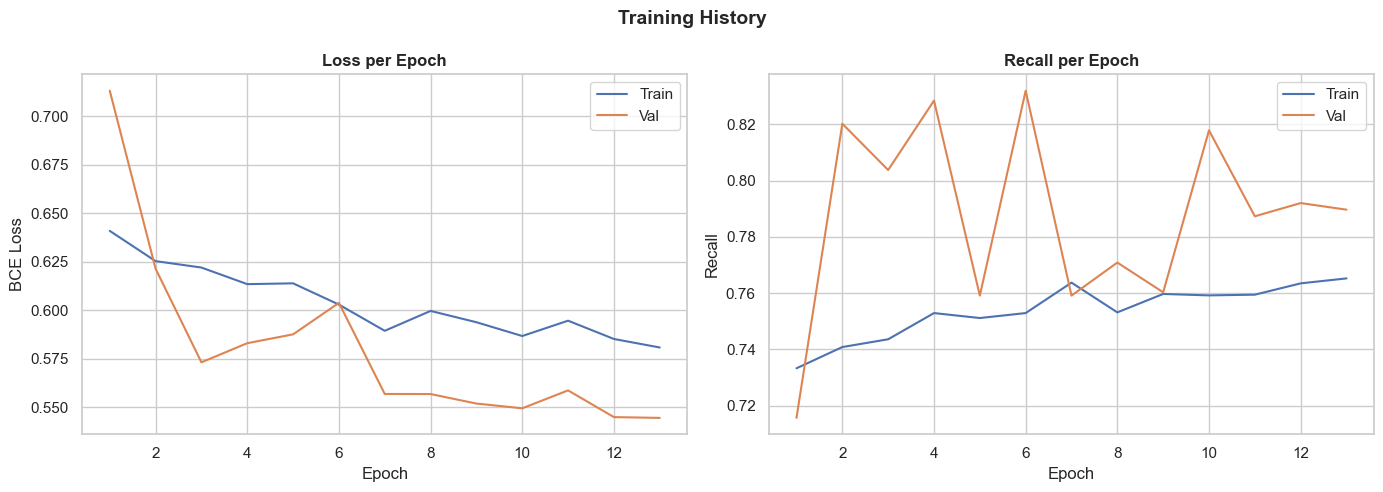

In [13]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_ran, history["train_loss"], label="Train")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val")
axes[0].set_title("Loss per Epoch", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend()

axes[1].plot(epochs_ran, history["train_recall"], label="Train")
axes[1].plot(epochs_ran, history["val_recall"],   label="Val")
axes[1].set_title("Recall per Epoch", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Recall")
axes[1].legend()

plt.suptitle("Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**What to look for in the training curves:**
- **Loss:** Both train and val loss should decrease. If val loss increases while train loss decreases, the model is overfitting — increase dropout or reduce model depth.
- **Recall:** Val recall should broadly track train recall. A large gap indicates overfitting. If both are low, the class weights may need increasing or the learning rate adjusting.
- **Early stopping:** The best checkpoint (saved to `checkpoints/best_model.pt`) is the epoch with highest val recall, not the final epoch.

## 6. Threshold Calibration

The default threshold of 0.5 is not appropriate for a safety-critical triage system. We use the validation set to find a threshold that maximises recall at acceptable precision.

**Target:** Recall ≥ 0.90 on the validation set. This means at most 1 in 10 cracked images is missed. The brief frames this as a triage system — human engineers review flagged images, so false positives are an inconvenience, not a safety failure. False negatives (missed cracks) are the safety risk.

In [14]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(CHECKPOINT / "best_model.pt", map_location=DEVICE))
model.eval()
print("Best checkpoint loaded.")

# ── Get val set predictions ───────────────────────────────────────────────────
_, _, val_labels, val_probs, val_paths, val_domains, val_flags = \
    run_epoch(val_loader, model, criterion)


Best checkpoint loaded.


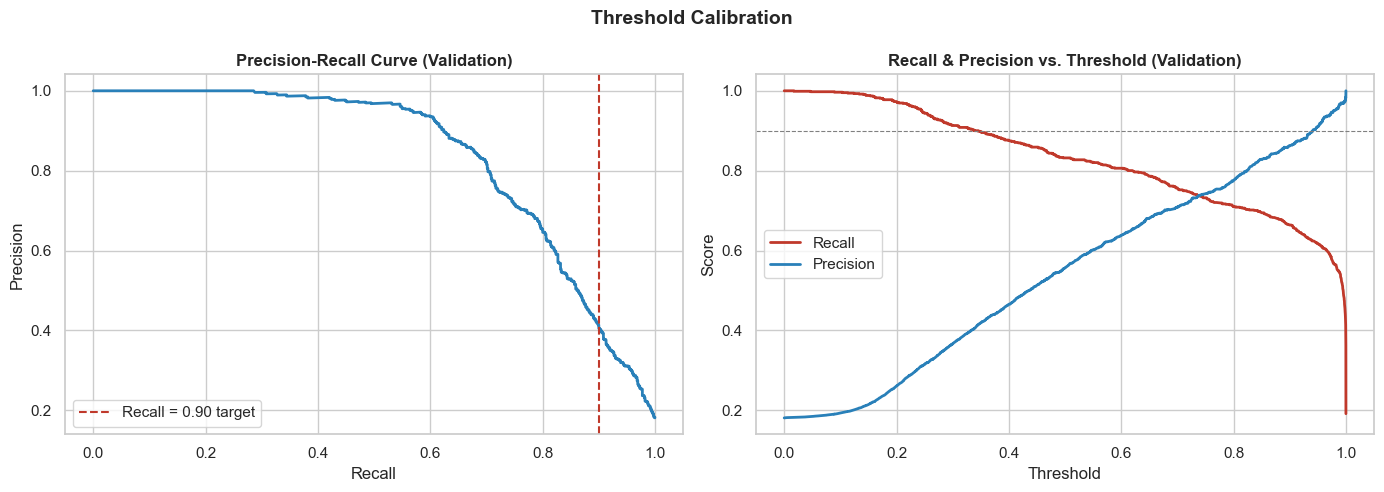

In [15]:
# ── Precision-Recall curve ────────────────────────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
axes[0].plot(recalls, precisions, color="#2980b9", linewidth=2)
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (Validation)", fontweight="bold")
axes[0].axvline(0.90, color="#c0392b", linestyle="--", label="Recall = 0.90 target")
axes[0].legend()

# Recall & Precision vs Threshold
axes[1].plot(thresholds, recalls[:-1],    label="Recall",    color="#c0392b", linewidth=2)
axes[1].plot(thresholds, precisions[:-1], label="Precision", color="#2980b9", linewidth=2)
axes[1].axhline(0.90, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Recall & Precision vs. Threshold (Validation)", fontweight="bold")
axes[1].legend()

plt.suptitle("Threshold Calibration", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [16]:
# ── Select threshold at recall ≥ 0.90 ────────────────────────────────────────
RECALL_TARGET = 0.90

# Find the highest threshold that still achieves recall >= target
valid_thresholds = thresholds[recalls[:-1] >= RECALL_TARGET]
if len(valid_thresholds) == 0:
    print("⚠️  Target recall not achieved — using threshold that maximises recall.")
    OPTIMAL_THRESHOLD = thresholds[np.argmax(recalls[:-1])]
else:
    OPTIMAL_THRESHOLD = valid_thresholds[-1]   # highest threshold (best precision) at target recall

val_preds_calibrated = (val_probs >= OPTIMAL_THRESHOLD).astype(int)
val_metrics = compute_metrics(val_labels, val_preds_calibrated, val_probs)

print(f"Optimal threshold: {OPTIMAL_THRESHOLD:.3f}")
print(f"\nValidation Metrics at Calibrated Threshold:")
for k, v in val_metrics.items():
    print(f"  {k:<12} {v:.4f}")


Optimal threshold: 0.345

Validation Metrics at Calibrated Threshold:
  Recall       0.9001
  Precision    0.4138
  F2           0.7288
  AUC-ROC      0.9205


## 7. Test Set Evaluation

We now apply the calibrated threshold to the **held-out test set** — data the model has never seen during training or threshold selection. Results are reported overall and broken down by domain to reveal surface-type-specific performance.

In [17]:
# ── Full test set evaluation ──────────────────────────────────────────────────
_, _, test_labels, test_probs, test_paths, test_domains, test_flags = \
    run_epoch(test_loader, model, criterion)
test_preds = (test_probs >= OPTIMAL_THRESHOLD).astype(int)

test_metrics = compute_metrics(test_labels, test_preds, test_probs)
print("Test Set Metrics:")
for k, v in test_metrics.items():
    print(f"  {k:<12} {v:.4f}")


Test Set Metrics:
  Recall       0.8871
  Precision    0.4274
  F2           0.7301
  AUC-ROC      0.9158


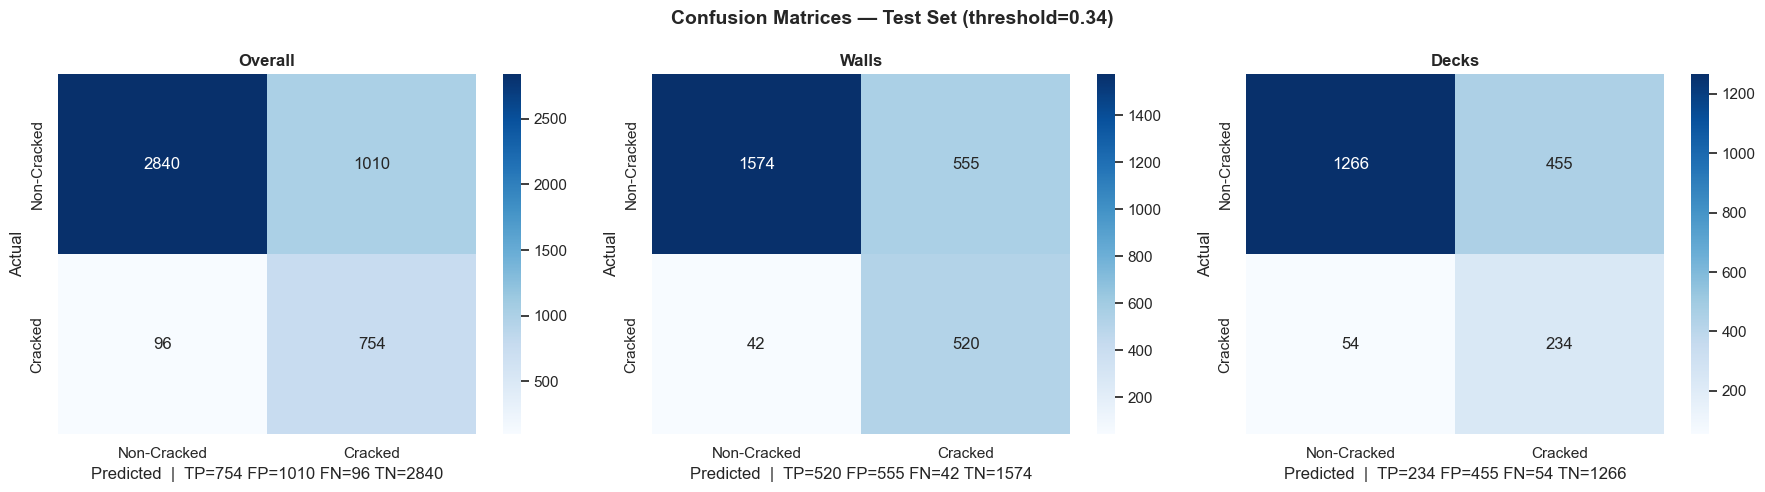

In [18]:
# ── Per-domain confusion matrices ─────────────────────────────────────────────
df_test_results = pd.DataFrame({
    "filepath":   test_paths,
    "domain":     test_domains,
    "flag":       test_flags,
    "true_label": test_labels.astype(int),
    "pred_label": test_preds,
    "prob":       test_probs,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall
plot_confusion_matrix(test_labels, test_preds, title="Overall", ax=axes[0])

# Per domain
for ax, domain in zip(axes[1:], ["Walls", "Decks"]):
    sub = df_test_results[df_test_results["domain"] == domain]
    plot_confusion_matrix(sub["true_label"], sub["pred_label"],
                          title=f"{domain}", ax=ax)

plt.suptitle(f"Confusion Matrices — Test Set (threshold={OPTIMAL_THRESHOLD:.2f})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [19]:
# ── Per-domain metric summary ─────────────────────────────────────────────────
rows = []
for domain in ["Walls", "Decks", "Overall"]:
    sub = df_test_results if domain == "Overall" else df_test_results[df_test_results["domain"] == domain]
    m   = compute_metrics(sub["true_label"], sub["pred_label"], sub["prob"])
    rows.append({"Domain": domain, **m})

df_metrics = pd.DataFrame(rows).set_index("Domain").round(4)
print(df_metrics.to_string())


         Recall  Precision      F2  AUC-ROC
Domain                                     
Walls    0.9253     0.4837  0.7824   0.9370
Decks    0.8125     0.3396  0.6355   0.8738
Overall  0.8871     0.4274  0.7301   0.9158


In [20]:
# ── Flagged-image recall ──────────────────────────────────────────────────────
# Flags are stored in HDF5 and returned by run_epoch — no CSV lookup needed
df_flagged_results = df_test_results[df_test_results["flag"] != "no flag"]

if len(df_flagged_results) > 0:
    flagged_recall = recall_score(df_flagged_results["true_label"],
                                  df_flagged_results["pred_label"], zero_division=0)
    print(f"Flagged-image subset (n={len(df_flagged_results):,}):")
    print(f"  Recall: {flagged_recall:.4f}")
    print(f"  (vs overall test recall: {test_metrics['Recall']:.4f})")
    print(f"\nFlag breakdown:")
    print(df_flagged_results["flag"].value_counts().to_string())
else:
    print("No flagged images found in test set — all may be in train split.")


Flagged-image subset (n=283):
  Recall: 0.8750
  (vs overall test recall: 0.8871)

Flag breakdown:
flag
noncracked_high_edges               190
very_bright                          46
very_dark                            34
noncracked_high_edges, very_dark     13


### 7.1 Evaluation Findings

*(Complete after running the cells above.)*

Report the following:
- Overall recall, F2, precision, AUC-ROC at the calibrated threshold
- Whether Walls or Decks recall is lower and why (refer to Phase 1 domain differences)
- Whether flagged-image recall is lower than overall recall — if so, the model is struggling with the confounder cases identified in Phase 1
- Any systematic pattern in the confusion matrix (e.g. FN concentrated in one domain)

## 8. Cross-Domain Diagnostic

We train two additional models:
- **B1:** Train on Walls only → evaluate on Decks only
- **B2:** Train on Decks only → evaluate on Walls only

If recall collapses in cross-domain evaluation, this is evidence the model is learning **surface texture** rather than **crack morphology** — consistent with the partial domain separability observed in the Phase 1 PCA.

This directly informs the client recommendation: single generic model vs. domain-specific models.

> These runs use the same architecture and hyperparameters. Training is capped at 20 epochs since the domain-specific datasets are smaller.

In [21]:
def build_domain_loaders(train_domain, test_domain):
    """Build train/test loaders filtered to a single domain from HDF5."""

    class DomainSubset(Dataset):
        """Wraps CrackDataset and filters to a single domain."""
        def __init__(self, split, domain, transform=None):
            self.base      = CrackDataset(split, transform=transform)
            # Pre-load all indices belonging to this domain
            with h5py.File(HDF5_PATH, "r") as f:
                domains = [f[f"{split}/domains"][i].decode()
                           for i in range(len(f[f"{split}/labels"]))]
            self.indices = [i for i, d in enumerate(domains) if d == domain]

        def __len__(self):
            return len(self.indices)

        def __getitem__(self, idx):
            return self.base[self.indices[idx]]

    tr_ds = DomainSubset("train", train_domain, transform=train_transforms)
    te_ds = DomainSubset("test",  test_domain,  transform=val_test_transforms)

    # Recompute pos_weight for this domain's class balance
    with h5py.File(HDF5_PATH, "r") as f:
        tr_labels = np.array([f["train/labels"][i] for i in tr_ds.indices])
    n_cr  = int(tr_labels.sum())
    n_ncr = len(tr_labels) - n_cr
    pw    = torch.tensor([n_ncr / n_cr], dtype=torch.float32).to(DEVICE)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return tr_loader, te_loader, pw


def cross_domain_run(train_domain, test_domain, epochs=20):
    """Train on train_domain, evaluate on test_domain. Returns test recall and F2."""
    print(f"\n── Train: {train_domain}  →  Test: {test_domain} ──")
    tr_loader, te_loader, pw = build_domain_loaders(train_domain, test_domain)

    m    = CrackCNN().to(DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt  = optim.Adam(m.parameters(), lr=LR)

    best_recall, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        run_epoch(tr_loader, m, crit, opt)
        _, vl_recall, _, _, _, _, _ = run_epoch(te_loader, m, crit)
        if vl_recall > best_recall:
            best_recall = vl_recall
            best_state  = {k: v.clone() for k, v in m.state_dict().items()}

    m.load_state_dict(best_state)
    _, _, labels, probs, _, _, _ = run_epoch(te_loader, m, crit)
    preds   = (probs >= OPTIMAL_THRESHOLD).astype(int)
    metrics = compute_metrics(labels, preds, probs)
    print(f"  Recall: {metrics['Recall']:.4f}  F2: {metrics['F2']:.4f}  "
          f"Precision: {metrics['Precision']:.4f}  AUC-ROC: {metrics['AUC-ROC']:.4f}")
    return metrics


In [22]:
# ── Run cross-domain experiments ──────────────────────────────────────────────
results_b1 = cross_domain_run(train_domain="Walls", test_domain="Decks")
results_b2 = cross_domain_run(train_domain="Decks", test_domain="Walls")

# ── Compare against intra-domain performance ──────────────────────────────────
cross_domain_summary = pd.DataFrame({
    "Train → Test": ["Walls → Walls (intra)", "Decks → Decks (intra)",
                     "Walls → Decks (cross)", "Decks → Walls (cross)"],
    "Recall":    [df_metrics.loc["Walls", "Recall"],    df_metrics.loc["Decks", "Recall"],
                  results_b1["Recall"], results_b2["Recall"]],
    "F2":        [df_metrics.loc["Walls", "F2"],        df_metrics.loc["Decks", "F2"],
                  results_b1["F2"],     results_b2["F2"]],
    "Precision": [df_metrics.loc["Walls", "Precision"], df_metrics.loc["Decks", "Precision"],
                  results_b1["Precision"], results_b2["Precision"]],
}).set_index("Train → Test").round(4)

print("\nCross-Domain Summary:")
print(cross_domain_summary.to_string())



── Train: Walls  →  Test: Decks ──
  Recall: 1.0000  F2: 0.4576  Precision: 0.1444  AUC-ROC: 0.6546

── Train: Decks  →  Test: Walls ──
  Recall: 0.9964  F2: 0.5678  Precision: 0.2087  AUC-ROC: 0.6702

Cross-Domain Summary:
                       Recall      F2  Precision
Train → Test                                    
Walls → Walls (intra)  0.9253  0.7824     0.4837
Decks → Decks (intra)  0.8125  0.6355     0.3396
Walls → Decks (cross)  1.0000  0.4576     0.1444
Decks → Walls (cross)  0.9964  0.5678     0.2087


### 8.1 Cross-Domain Findings

*(Complete after running the cells above.)*

**Interpreting the results:**
- If cross-domain recall drops significantly (>10 percentage points) vs intra-domain recall, the model is learning texture, not crack morphology — domain-specific models should be recommended to the client.
- If cross-domain recall holds up, the model has generalised to crack morphology — a single generic model is defensible.
- Compare this result against the Phase 1 PCA finding: if Walls and Decks were clearly separable in PCA space, a large recall drop is expected and confirms the PCA prediction.

**Client recommendation:** Based on cross-domain recall, make a clear recommendation in the Phase 3 report — single generic model or separate models per asset type. Justify with these numbers.